<a href="https://colab.research.google.com/github/Rishitha110506/Machine-Learning/blob/main/ML_Lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MACHINE LEARNING ASSIGNMENT 08


NAME : KAMPALLI RISHITHA

REG NO : BL.SC.U4AIE24020

SEC : D.Sec


loading dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving BERT_Embeddings.xlsx to BERT_Embeddings.xlsx


A1

In [3]:
import pandas as pd
import numpy as np
df = pd.read_excel("BERT_Embeddings.xlsx")


X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values


def summation(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

def step_activation(x):
    return 1 if x >= 0 else 0

def bipolar_step_activation(x):
    return 1 if x >= 0 else -1

def sigmoid_activation(x):
    return 1 / (1 + np.exp(-x))

def tanh_activation(x):
    return np.tanh(x)

def relu_activation(x):
    return np.maximum(0, x)

def leaky_relu_activation(x, alpha=0.01):
    return x if x > 0 else alpha * x

def comparator_error(y_true, y_pred):
    return (y_true - y_pred) ** 2


sample_input = X[0]
sample_weights = np.random.rand(X.shape[1])
sample_bias = 0.5

summed_value = summation(sample_input, sample_weights, sample_bias)
print("Summation output:", summed_value)

print("Step activation:", step_activation(summed_value))
print("Bipolar step activation:", bipolar_step_activation(summed_value))
print("Sigmoid activation:", sigmoid_activation(summed_value))
print("Tanh activation:", tanh_activation(summed_value))
print("ReLU activation:", relu_activation(summed_value))
print("Leaky ReLU activation:", leaky_relu_activation(summed_value))


target = y[0]
pred = step_activation(summed_value)
print("Comparator error:", comparator_error(target, pred))


Summation output: -5.7734113575024075
Step activation: 0
Bipolar step activation: -1
Sigmoid activation: 0.0030994962918867233
Tanh activation: -0.9999806667703901
ReLU activation: 0.0
Leaky ReLU activation: -0.057734113575024074
Comparator error: 9


A2

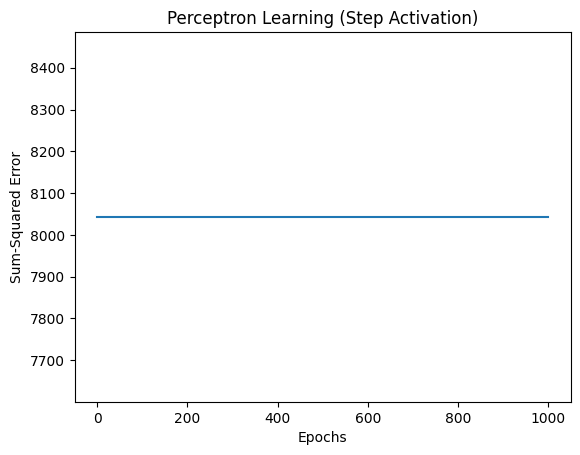

Final Weights: [ 4.13039555e+04  9.68769984e+03  9.01422259e+03  1.20155804e+04
  3.06309990e+04  2.31615420e+03  1.41155925e+04 -2.65182147e+03
 -3.53279251e+03 -1.93498458e+03  2.96879765e+03  2.31033406e+04
 -7.51957247e+03  5.18234743e+04 -6.92163573e+04 -2.05084462e+04
  5.93767142e+04  3.83844323e+03  1.66572158e+03 -1.19189099e+04
 -2.49631123e+04 -2.53173167e+04 -1.20706438e+03 -6.63569090e+02
 -1.55430441e+04 -7.47955729e+04  3.67305930e+04  4.56474520e+04
 -1.41712009e+04  7.67909113e+04 -4.00750836e+03  1.91120850e+04
  1.69881358e+04  1.49505258e+03 -2.14408630e+04 -5.35524402e+03
  6.77892063e+03  4.95096828e+04 -8.36180083e+03  3.22805499e+04
  2.56334651e+04  1.36661195e+04  2.82706303e+04 -1.06444148e+04
  5.54855509e+04 -1.38472008e+04 -3.01181978e+03  4.67715437e+04
 -5.86718472e+04  2.60902347e+04  3.77842216e+04 -3.79792607e+04
 -1.68353747e+03  3.33756261e+04 -2.02539548e+04 -1.69429579e+04
  6.07402094e+03 -8.88127784e+02 -1.18927735e+04  6.85593005e+04
 -2.749839

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_excel("BERT_Embeddings.xlsx")


X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values


def step_activation(x):
    return 1 if x >= 0 else 0


def summation(inputs, weights, bias):
    return np.dot(inputs, weights) + bias


def comparator_error(y_true, y_pred):
    return (y_true - y_pred) ** 2


def train_perceptron_step(X, y, lr=0.05, max_epochs=1000, tol=0.002):

    weights = np.array([0.2, -0.75] + [0]*(X.shape[1]-2))
    bias = 10
    errors = []

    for epoch in range(max_epochs):
        total_error = 0
        for xi, target in zip(X, y):
            summ = summation(xi, weights, bias)
            output = step_activation(summ)
            error = target - output
            weights += lr * error * xi
            bias += lr * error
            total_error += error**2
        errors.append(total_error)
        if total_error <= tol:
            break


    plt.plot(errors)
    plt.xlabel("Epochs")
    plt.ylabel("Sum-Squared Error")
    plt.title("Perceptron Learning (Step Activation)")
    plt.show()

    return weights, bias, len(errors)


weights, bias, epochs = train_perceptron_step(X, y)
print("Final Weights:", weights)
print("Final Bias:", bias)
print("Epochs until convergence:", epochs)


A3

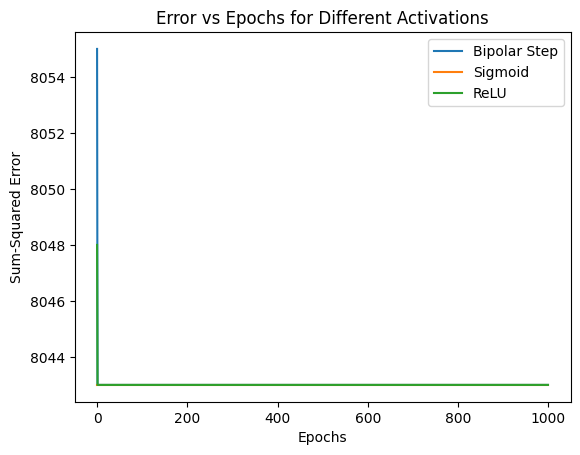

Iterations to converge: {'Bipolar Step': 1000, 'Sigmoid': 1000, 'ReLU': 1000}


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_excel("BERT_Embeddings.xlsx")


X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values


def bipolar_step_activation(x):
    if x > 0: return 1
    elif x == 0: return 0
    else: return -1

def sigmoid_activation(x):
    return 1 / (1 + np.exp(-x))

def relu_activation(x):
    return np.maximum(0, x)


def summation(inputs, weights, bias):
    return np.dot(inputs, weights) + bias


def train_with_activation(X, y, activation_fn, lr=0.05, max_epochs=1000, tol=0.002):
    n_features = X.shape[1]
    weights = np.random.uniform(-0.5, 0.5, n_features)
    bias = np.random.uniform(-0.5, 0.5)
    errors = []

    for epoch in range(max_epochs):
        total_error = 0
        for xi, target in zip(X, y):
            summ = summation(xi, weights, bias)
            output = activation_fn(summ)


            if activation_fn in [sigmoid_activation, relu_activation]:
                output = 1 if output >= 0.5 else 0

            error = target - output
            weights += lr * error * xi
            bias += lr * error
            total_error += error**2
        errors.append(total_error)
        if total_error <= tol:
            break
    return len(errors), errors


def compare_activations(X, y):
    activations = {
        "Bipolar Step": bipolar_step_activation,
        "Sigmoid": sigmoid_activation,
        "ReLU": relu_activation
    }
    results = {}
    for name, fn in activations.items():
        epochs, errs = train_with_activation(X, y, fn)
        results[name] = epochs
        plt.plot(errs, label=name)
    plt.xlabel("Epochs")
    plt.ylabel("Sum-Squared Error")
    plt.legend()
    plt.title("Error vs Epochs for Different Activations")
    plt.show()
    return results


results = compare_activations(X, y)
print("Iterations to converge:", results)


A4

Learning rate 0.1 -> Epochs until convergence: 1000
Learning rate 0.2 -> Epochs until convergence: 1000
Learning rate 0.3 -> Epochs until convergence: 1000
Learning rate 0.4 -> Epochs until convergence: 1000
Learning rate 0.5 -> Epochs until convergence: 1000
Learning rate 0.6 -> Epochs until convergence: 1000
Learning rate 0.7 -> Epochs until convergence: 1000
Learning rate 0.8 -> Epochs until convergence: 1000
Learning rate 0.9 -> Epochs until convergence: 1000
Learning rate 1.0 -> Epochs until convergence: 1000


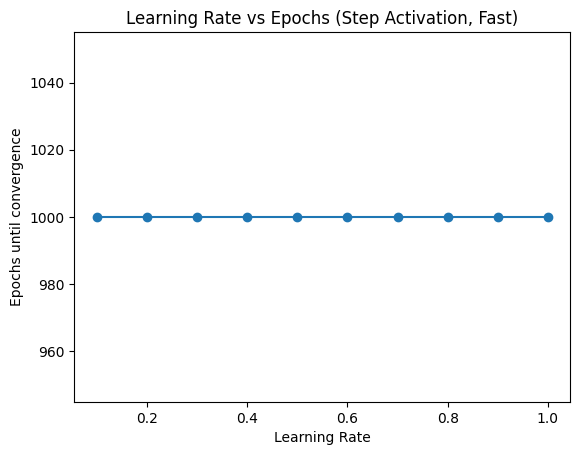

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("BERT_Embeddings.xlsx")
X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

def step_activation(x):
    return (x >= 0).astype(int)

def train_perceptron_step_fast(X, y, lr, max_epochs=1000, tol=0.002):
    n_samples, n_features = X.shape
    weights = np.array([0.2, -0.75] + [0]*(n_features-2))
    bias = 10
    errors = []

    for epoch in range(max_epochs):
        summ = np.dot(X, weights) + bias
        outputs = step_activation(summ)

        error = y - outputs
        total_error = np.sum(error**2)
        errors.append(total_error)

        weights += lr * np.dot(error, X) / n_samples
        bias += lr * np.mean(error)

        if total_error <= tol:
            break
    return len(errors)

learning_rates = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
epochs_list = []

for lr in learning_rates:
    epochs = train_perceptron_step_fast(X, y, lr)
    epochs_list.append(epochs)
    print(f"Learning rate {lr} -> Epochs until convergence: {epochs}")

plt.plot(learning_rates, epochs_list, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Epochs until convergence")
plt.title("Learning Rate vs Epochs (Step Activation, Fast)")
plt.show()

A5

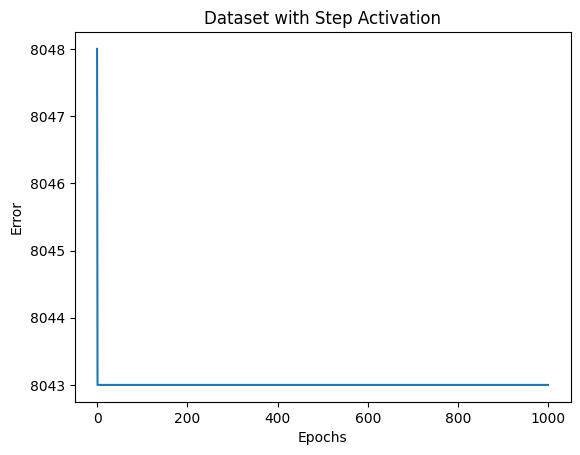

Step activation epochs: 1000


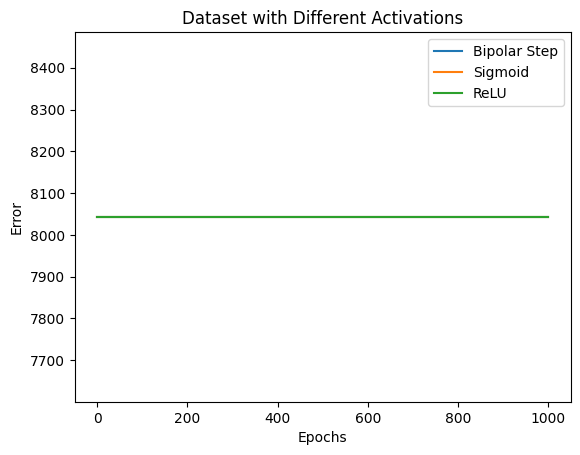

Iterations to converge: {'Bipolar Step': 1000, 'Sigmoid': 1000, 'ReLU': 1000}


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("BERT_Embeddings.xlsx")

X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

def summation(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

def step_activation(x):
    return 1 if x >= 0 else 0

def bipolar_step_activation(x):
    if x > 0: return 1
    elif x == 0: return 0
    else: return -1

def sigmoid_activation(x):
    return 1 / (1 + np.exp(-x))

def relu_activation(x):
    return np.maximum(0, x)

def comparator_error(y_true, y_pred):
    return (y_true - y_pred) ** 2

def train_perceptron(X, y, activation_fn, lr=0.1, max_epochs=1000, tol=0.002):
    weights = np.random.uniform(-0.5,0.5,X.shape[1])
    bias = np.random.uniform(-0.5,0.5)
    errors = []

    for epoch in range(max_epochs):
        total_error = 0
        for xi, target in zip(X,y):
            summ = summation(xi, weights, bias)
            output = activation_fn(summ)

            if activation_fn in [sigmoid_activation, relu_activation]:
                output = 1 if output >= 0.5 else 0

            error = target - output
            weights += lr * error * xi
            bias += lr * error
            total_error += error**2
        errors.append(total_error)
        if total_error <= tol:
            break
    return len(errors), errors

epochs_step, errs_step = train_perceptron(X,y,step_activation)
plt.plot(errs_step)
plt.title("Dataset with Step Activation")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()
print("Step activation epochs:", epochs_step)

activations = {
    "Bipolar Step": bipolar_step_activation,
    "Sigmoid": sigmoid_activation,
    "ReLU": relu_activation
}
results = {}
for name, fn in activations.items():
    epochs, errs = train_perceptron(X,y,fn)
    results[name] = epochs
    plt.plot(errs, label=name)

plt.title("Dataset with Different Activations")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend()
plt.show()

print("Iterations to converge:", results)

A6

Final Weights: [ 2.53977479e+01  5.87463761e+00  5.60583191e+00  7.48560361e+00
  1.86999519e+01  1.68757661e+00  8.16729815e+00 -1.91492046e+00
 -1.91372720e+00 -7.69780284e-01  1.48677521e+00  1.37090914e+01
 -4.47031633e+00  3.11521973e+01 -4.18576905e+01 -1.22123932e+01
  3.58587647e+01  2.35101514e+00  5.69741418e-01 -6.92252942e+00
 -1.53077802e+01 -1.57414660e+01 -9.52337387e-01 -3.32564252e-02
 -9.31618386e+00 -4.50933832e+01  2.19952552e+01  2.74008688e+01
 -8.77384375e+00  4.60610461e+01 -2.19055357e+00  1.20429890e+01
  1.05468831e+01  8.10930367e-01 -1.33112144e+01 -3.34427855e+00
  3.74533636e+00  3.02028464e+01 -4.98861517e+00  1.98627662e+01
  1.59765716e+01  7.86380297e+00  1.73944659e+01 -6.34960642e+00
  3.36658286e+01 -8.67017494e+00 -1.72271141e+00  2.78993606e+01
 -3.55285605e+01  1.55720016e+01  2.25605321e+01 -2.24751862e+01
 -1.26999559e+00  2.00372784e+01 -1.25915668e+01 -9.78415498e+00
  4.16692502e+00 -5.96215677e-02 -6.83998245e+00  4.17423031e+01
 -1.695122

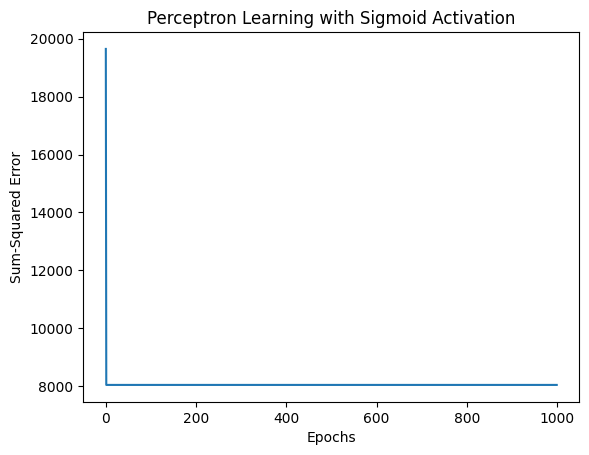

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("BERT_Embeddings.xlsx")

X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

def sigmoid_activation(x):
    return 1 / (1 + np.exp(-x))

def summation(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

def train_perceptron_sigmoid(X, y, lr=0.1, max_epochs=1000, tol=0.002):
    n_features = X.shape[1]
    weights = np.random.uniform(-0.5, 0.5, n_features)
    bias = np.random.uniform(-0.5, 0.5)
    errors = []

    for epoch in range(max_epochs):
        summ = np.dot(X, weights) + bias
        outputs = sigmoid_activation(summ)

        preds = (outputs >= 0.5).astype(int)

        error = y - preds
        total_error = np.sum(error**2)
        errors.append(total_error)

        weights += lr * np.dot(error, X) / len(X)
        bias += lr * np.mean(error)

        if total_error <= tol:
            break

    return weights, bias, len(errors), errors

weights, bias, epochs, errors = train_perceptron_sigmoid(X, y, lr=0.1)

print("Final Weights:", weights)
print("Final Bias:", bias)
print("Epochs until convergence:", epochs)

plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Sum-Squared Error")
plt.title("Perceptron Learning with Sigmoid Activation")
plt.show()

A7

Perceptron (Sigmoid) Weights: [ 2.44714154e+01  6.29333492e+00  5.37836434e+00  7.37713714e+00
  1.86165312e+01  1.22635556e+00  8.77282465e+00 -1.27850302e+00
 -2.44554839e+00 -1.21452676e+00  1.41802203e+00  1.34658599e+01
 -4.06171210e+00  3.08635677e+01 -4.14020833e+01 -1.24367378e+01
  3.60481483e+01  2.30960585e+00  6.86638802e-01 -6.82367647e+00
 -1.52856035e+01 -1.53992797e+01 -7.38077268e-01 -8.57919075e-01
 -9.08897055e+00 -4.53043654e+01  2.25489363e+01  2.78493588e+01
 -8.98708026e+00  4.67016115e+01 -1.92557011e+00  1.11467213e+01
  1.05026395e+01  1.13417293e+00 -1.24574665e+01 -3.10396490e+00
  3.95317517e+00  3.01880288e+01 -4.86676565e+00  1.90410413e+01
  1.56980043e+01  7.81690085e+00  1.65842907e+01 -6.71992011e+00
  3.36465939e+01 -8.20568082e+00 -1.37637177e+00  2.82471274e+01
 -3.58342333e+01  1.54879957e+01  2.33225394e+01 -2.28090832e+01
 -8.60585464e-01  1.97148070e+01 -1.18957593e+01 -1.01090174e+01
  4.01966598e+00 -5.48133129e-01 -7.06826635e+00  4.18604990

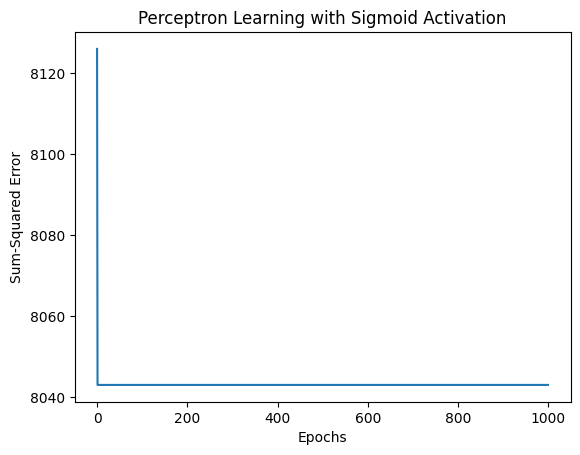

Pseudo-inverse Weights (including bias): [ -4564.2327067   -4476.63014097  -4495.67734499  -4612.15280675
  -4488.54061281  -4478.65005594  -4391.42914867  -4545.34528331
  -4271.97008517  -4722.76439599  -4465.80834347  -4465.70461685
  -4146.19740785  -4588.70039589  -4641.02943075  -4445.5699685
  -4582.95115117  -4374.61325705  -4500.91598464  -4463.47826845
  -4511.46210112  -4532.41256449  -4602.75774098  -4448.17233719
  -4486.1533138   -4498.85433912  -4299.95495455  -4423.99338506
  -4226.49896517  -3952.18322177  -4452.95047084  -4438.79022775
  -4406.07827207  -4574.084412    -4465.38266799  -4427.35293493
  -4520.10608781  -4373.03961283  -4572.29245487  -4521.64378278
  -4540.27329573  -4608.1323377   -4243.08231781  -4459.30108015
  -4317.17215918  -4231.86111348  -4587.04853252  -4192.7179559
  -4440.20939004  -4434.2013609   -4294.88592231  -4495.11122107
  -4463.47416427  -4336.02141202  -4523.3872037   -4429.09358777
  -4301.68359663  -4462.80192013  -4661.18144604  -

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("BERT_Embeddings.xlsx")

X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values

def sigmoid_activation(x):
    return 1 / (1 + np.exp(-x))

def train_perceptron_sigmoid(X, y, lr=0.1, max_epochs=1000, tol=0.002):
    n_features = X.shape[1]
    weights = np.random.uniform(-0.5, 0.5, n_features)
    bias = np.random.uniform(-0.5, 0.5)
    errors = []

    for epoch in range(max_epochs):
        summ = np.dot(X, weights) + bias
        outputs = sigmoid_activation(summ)
        preds = (outputs >= 0.5).astype(int)

        error = y - preds
        total_error = np.sum(error**2)
        errors.append(total_error)

        weights += lr * np.dot(error, X) / len(X)
        bias += lr * np.mean(error)

        if total_error <= tol:
            break

    return weights, bias, len(errors), errors

weights_p, bias_p, epochs, errors = train_perceptron_sigmoid(X, y)
print("Perceptron (Sigmoid) Weights:", weights_p)
print("Bias:", bias_p)
print("Epochs until convergence:", epochs)

plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Sum-Squared Error")
plt.title("Perceptron Learning with Sigmoid Activation")
plt.show()


X_bias = np.hstack([X, np.ones((X.shape[0],1))])

W_pinv = np.linalg.pinv(X_bias).dot(y)

print("Pseudo-inverse Weights (including bias):", W_pinv)


summ_pinv = np.dot(X_bias, W_pinv)
outputs_pinv = sigmoid_activation(summ_pinv)
preds_pinv = (outputs_pinv >= 0.5).astype(int)

accuracy_pinv = np.mean(preds_pinv == y)
print("Pseudo-inverse Accuracy:", accuracy_pinv)


summ_p = np.dot(X, weights_p) + bias_p
outputs_p = sigmoid_activation(summ_p)
preds_p = (outputs_p >= 0.5).astype(int)
accuracy_p = np.mean(preds_p == y)
print("Perceptron Accuracy:", accuracy_p)

A8


Hidden Weights: [[ 0.4232653   0.7484315 ]
 [ 0.28817087  0.41306685]
 [ 0.32538666  0.03528849]
 ...
 [ 0.21446003  0.23705111]
 [ 0.48489228  0.38433357]
 [-0.25694329  0.34236596]]
Output Weights: [[72.72226994]
 [ 9.29397292]]
Epochs until convergence: 1000


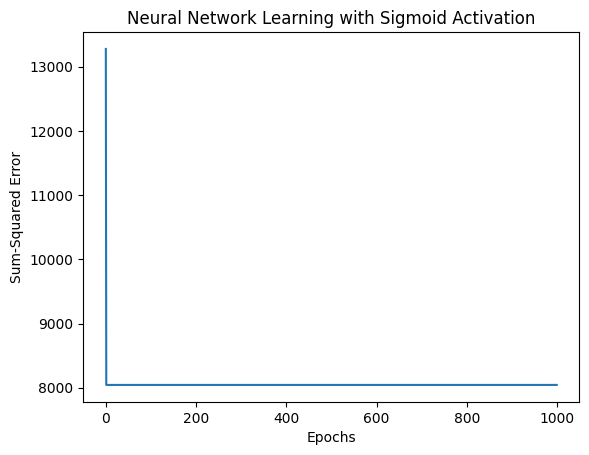

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("BERT_Embeddings.xlsx")

X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values.reshape(-1,1)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def train_nn(X, y, hidden_size=2, lr=0.05, max_epochs=1000, tol=0.002):
    n_samples, n_features = X.shape
    n_outputs = 1

    W_hidden = np.random.uniform(-0.5, 0.5, (n_features, hidden_size))
    b_hidden = np.random.uniform(-0.5, 0.5, (1, hidden_size))
    W_output = np.random.uniform(-0.5, 0.5, (hidden_size, n_outputs))
    b_output = np.random.uniform(-0.5, 0.5, (1, n_outputs))

    errors = []

    for epoch in range(max_epochs):
        hidden_input = np.dot(X, W_hidden) + b_hidden
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, W_output) + b_output
        final_output = sigmoid(final_input)


        error = y - final_output
        total_error = np.sum(error**2)
        errors.append(total_error)


        d_output = error * sigmoid_derivative(final_output)
        d_hidden = np.dot(d_output, W_output.T) * sigmoid_derivative(hidden_output)


        W_output += lr * np.dot(hidden_output.T, d_output)
        b_output += lr * np.sum(d_output, axis=0, keepdims=True)

        W_hidden += lr * np.dot(X.T, d_hidden)
        b_hidden += lr * np.sum(d_hidden, axis=0, keepdims=True)

        if total_error <= tol:
            break

    return W_hidden, W_output, b_hidden, b_output, len(errors), errors


W_hidden, W_output, b_hidden, b_output, epochs, errors = train_nn(X, y)

print("Hidden Weights:", W_hidden)
print("Output Weights:", W_output)
print("Epochs until convergence:", epochs)


plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Sum-Squared Error")
plt.title("Neural Network Learning with Sigmoid Activation")
plt.show()

A9

Hidden Weights:
 [[ 0.14697211  0.24065079  0.63748042  0.39061415]
 [-0.53316168 -0.14654869  0.52401405  0.03836684]
 [-0.26249701 -0.19127263 -0.12369009  0.48058443]
 ...
 [ 0.02520547  0.09815513  0.23307385  0.18010941]
 [ 0.03241011  0.01668932  0.59354588  0.0655955 ]
 [-0.28459319  0.01576536  0.21074796  0.13696861]]
Output Weights:
 [[ 3.62811386]
 [38.23674114]
 [52.06399235]
 [12.12395262]]
Epochs until convergence: 1000


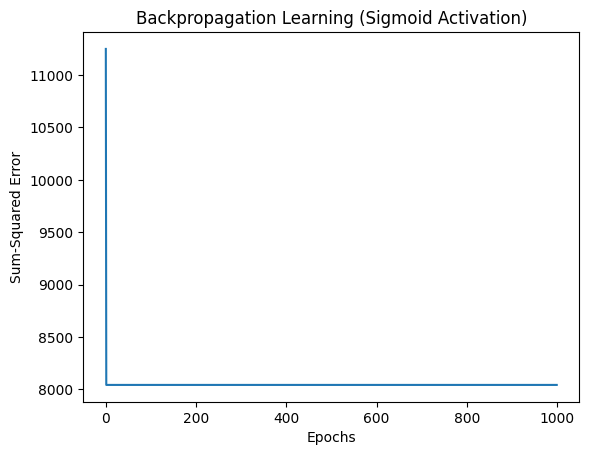

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("BERT_Embeddings.xlsx")

X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values.reshape(-1,1)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def train_backprop(X, y, hidden_size=4, lr=0.05, max_epochs=1000, tol=0.002):
    n_samples, n_features = X.shape
    n_outputs = 1

    W_hidden = np.random.uniform(-0.5, 0.5, (n_features, hidden_size))
    b_hidden = np.random.uniform(-0.5, 0.5, (1, hidden_size))
    W_output = np.random.uniform(-0.5, 0.5, (hidden_size, n_outputs))
    b_output = np.random.uniform(-0.5, 0.5, (1, n_outputs))

    errors = []

    for epoch in range(max_epochs):

        hidden_input = np.dot(X, W_hidden) + b_hidden
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, W_output) + b_output
        final_output = sigmoid(final_input)


        error = y - final_output
        total_error = np.sum(error**2)
        errors.append(total_error)


        d_output = error * sigmoid_derivative(final_output)
        d_hidden = np.dot(d_output, W_output.T) * sigmoid_derivative(hidden_output)


        W_output += lr * np.dot(hidden_output.T, d_output)
        b_output += lr * np.sum(d_output, axis=0, keepdims=True)

        W_hidden += lr * np.dot(X.T, d_hidden)
        b_hidden += lr * np.sum(d_hidden, axis=0, keepdims=True)

        if total_error <= tol:
            break

    return W_hidden, W_output, b_hidden, b_output, len(errors), errors


W_hidden, W_output, b_hidden, b_output, epochs, errors = train_backprop(X, y)

print("Hidden Weights:\n", W_hidden)
print("Output Weights:\n", W_output)
print("Epochs until convergence:", epochs)


plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Sum-Squared Error")
plt.title("Backpropagation Learning (Sigmoid Activation)")
plt.show()


A10

Hidden Weights:
 [[-0.07311431 -0.30124057  0.11068075  0.10586222]
 [ 0.11337307 -0.0665063  -0.27434124 -0.28781213]
 [-0.15593444 -0.31637018  0.42090407  0.09633489]
 ...
 [ 0.01565419  0.05605259 -0.07844879 -0.61689366]
 [ 0.46241337  0.03082541 -0.12926526  0.3555608 ]
 [-0.38531229 -0.07771838 -0.17034952  0.36500609]]
Output Weights:
 [[-18.76703303  16.01127468]
 [-21.96720931  18.88686334]
 [-21.31343365  18.41671216]
 [ -3.88320672   3.22127178]]
Epochs until convergence: 2


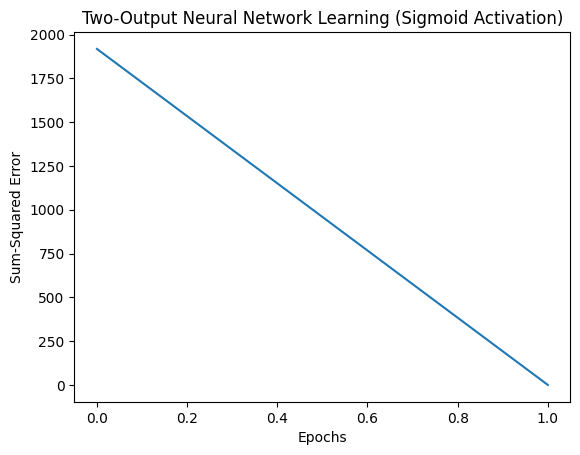

Classification Accuracy: 1.0


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("BERT_Embeddings.xlsx")

X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values


y_two = np.array([[1,0] if val==0 else [0,1] for val in y])


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)


def train_nn_two_outputs(X, y, hidden_size=4, lr=0.05, max_epochs=1000, tol=0.002):
    n_samples, n_features = X.shape
    n_outputs = y.shape[1]


    W_hidden = np.random.uniform(-0.5, 0.5, (n_features, hidden_size))
    b_hidden = np.random.uniform(-0.5, 0.5, (1, hidden_size))
    W_output = np.random.uniform(-0.5, 0.5, (hidden_size, n_outputs))
    b_output = np.random.uniform(-0.5, 0.5, (1, n_outputs))

    errors = []

    for epoch in range(max_epochs):

        hidden_input = np.dot(X, W_hidden) + b_hidden
        hidden_output = sigmoid(hidden_input)

        final_input = np.dot(hidden_output, W_output) + b_output
        final_output = sigmoid(final_input)


        error = y - final_output
        total_error = np.sum(error**2)
        errors.append(total_error)


        d_output = error * sigmoid_derivative(final_output)
        d_hidden = np.dot(d_output, W_output.T) * sigmoid_derivative(hidden_output)


        W_output += lr * np.dot(hidden_output.T, d_output)
        b_output += lr * np.sum(d_output, axis=0, keepdims=True)

        W_hidden += lr * np.dot(X.T, d_hidden)
        b_hidden += lr * np.sum(d_hidden, axis=0, keepdims=True)

        if total_error <= tol:
            break

    return W_hidden, W_output, b_hidden, b_output, len(errors), errors, final_output


W_hidden, W_output, b_hidden, b_output, epochs, errors, outputs = train_nn_two_outputs(X, y_two)

print("Hidden Weights:\n", W_hidden)
print("Output Weights:\n", W_output)
print("Epochs until convergence:", epochs)


plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Sum-Squared Error")
plt.title("Two-Output Neural Network Learning (Sigmoid Activation)")
plt.show()


preds = np.argmax(outputs, axis=1)
true = np.argmax(y_two, axis=1)
accuracy = np.mean(preds == true)
print("Classification Accuracy:", accuracy)


A11

MLPClassifier Accuracy: 0.6759287224403503
Confusion Matrix:
 [[ 119  132  201]
 [  18  647  466]
 [  16  240 1472]]
Classification Report:
               precision    recall  f1-score   support

           1       0.78      0.26      0.39       452
           2       0.63      0.57      0.60      1131
           3       0.69      0.85      0.76      1728

    accuracy                           0.68      3311
   macro avg       0.70      0.56      0.59      3311
weighted avg       0.68      0.68      0.66      3311



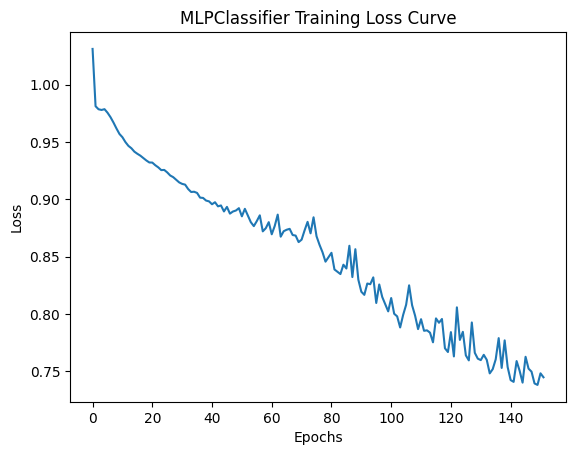

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt


df = pd.read_excel("BERT_Embeddings.xlsx")


X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values


mlp = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='logistic',
    solver='sgd',
    learning_rate_init=0.05,
    max_iter=1000,
    tol=0.002,
    random_state=42
)


mlp.fit(X, y)


y_pred = mlp.predict(X)


acc = accuracy_score(y, y_pred)
print("MLPClassifier Accuracy:", acc)
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
print("Classification Report:\n", classification_report(y, y_pred))


plt.plot(mlp.loss_curve_)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLPClassifier Training Loss Curve")
plt.show()


A12

MLPClassifier Accuracy: 0.9960736937481124
Confusion Matrix:
 [[ 444    0    8]
 [   1 1127    3]
 [   1    0 1727]]
Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.98      0.99       452
           2       1.00      1.00      1.00      1131
           3       0.99      1.00      1.00      1728

    accuracy                           1.00      3311
   macro avg       1.00      0.99      0.99      3311
weighted avg       1.00      1.00      1.00      3311



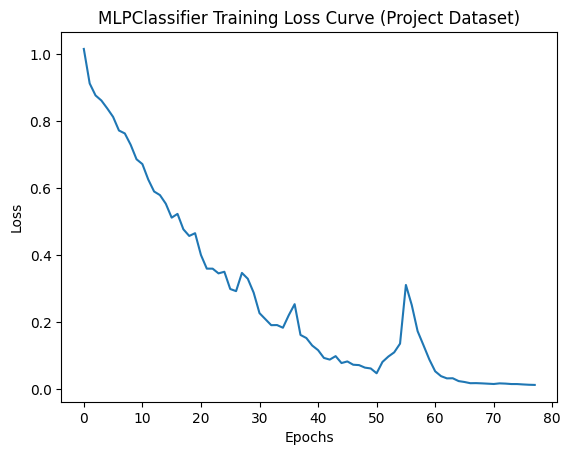

In [13]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt


df = pd.read_excel("BERT_Embeddings.xlsx")


X = df.drop(columns=['label','Student','Teacher']).values
y = df['label'].values


mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=1000,
    tol=0.002,
    random_state=42
)


mlp.fit(X, y)


y_pred = mlp.predict(X)


acc = accuracy_score(y, y_pred)
print("MLPClassifier Accuracy:", acc)
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
print("Classification Report:\n", classification_report(y, y_pred))


plt.plot(mlp.loss_curve_)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLPClassifier Training Loss Curve (Project Dataset)")
plt.show()
